# Laboratorio de regresión - 1

## Regresión lineal simple

|                |   |
:----------------|---|
| **Nombre**     |  Carlos Enrique Nieves Ochoa |
| **Fecha**      |  24 de Agosto de 2026 |
| **Expediente** |  758210 |

La regresión lineal es una herramienta útil para predecir una respuesta cuantitativa. Sirve como un punto de partida a pesar de que existen soluciones más modernas.

Observa la siguiente gráfica.

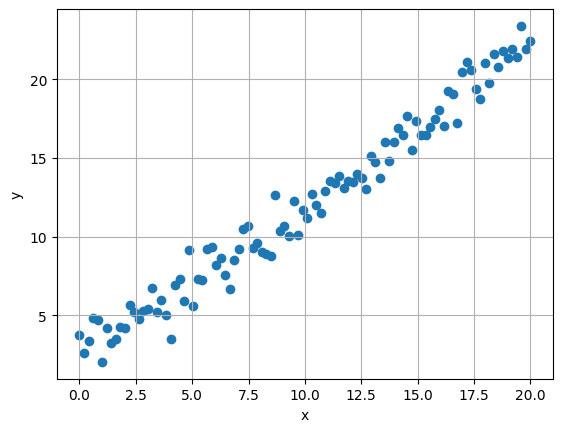

In [1]:
import matplotlib.pyplot as plt; import numpy as np
%matplotlib inline
np.random.seed(0)
x = np.linspace(0, 20, 100); y = 2 + x + np.random.normal(0, 1, 100)
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y); plt.grid()

**¿Hay alguna relación entre $y$ y $x$?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- **¿Por qué?** 

Sí, porque se nota visualmente que conforme aumenta la variable x, aumenta la variable y.

- Si hubiera una asociación, **¿qué tan fuerte es?**

Mucho porque prácticamente luce como una línea recta.

## Regresión lineal simple

Un método sencillo para predecir una variable cuantitativa $Y$ dado un solo predictor $X$. Podemos escribir esta relación como:

$$ Y \approx \beta_0 + \beta_1 X$$


A $\beta_0$ y $\beta_1$ se le conoce como los coeficientes o parámetros del modelo. Una vez que usamos los datos históricos para producir estimados $\hat{\beta_0}$ y $\hat{\beta_1}$, podemos predecir el resultado de la variable $y$ basándonos en $x$
$$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x $$

donde $\hat{y}$ indica una predicción de $Y$ basado en $X = x$. (El símbolo $\hat{ }$ se usa para hacer notar que es sólo una estimación de un parámetro desconocido)

### Estimando coeficientes

$\beta_0$ y $\beta_1$ son desconocidos. Se deben estimar usando los datos antes de poder predecir. 

$ (x_1, y_1), (x_2, y_2), ..., (x_n, y_n) $ representa $n$ observaciones, cada una con datos medidos para $X$ y $Y$.

Nuestros datos contienen 100 muestras en pares ordenados $(x_i, y_i)$. Nuestra meta actual es encontrar $\hat{\beta_0}$ y $\hat{\beta_1}$ tal que exista un modelo lineal que se ajuste bien a los datos ($y_i \approx \hat{\beta_0} + \hat{\beta_1}x_i$  para $ i=1,...,n$).

**¿Qué significa "que se ajuste bien"?**

Observa las 3 propuestas de lineas para ajustar los puntos.

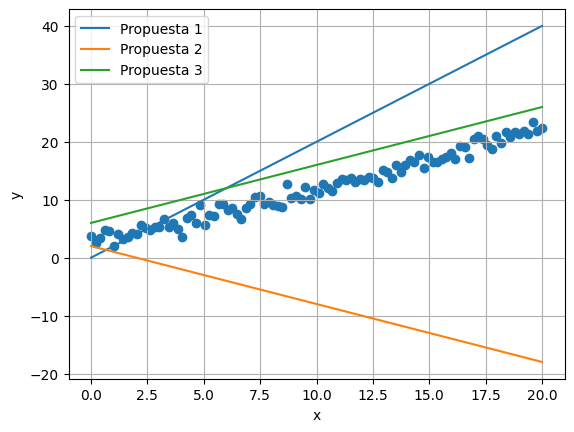

In [2]:
y_pred1 = 2*x; y_pred2 = -x + 2; y_pred3 = 6 + x
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y); plt.grid()
plt.plot(x, y_pred1, label="Propuesta 1"); plt.plot(x, y_pred2, label="Propuesta 2"); plt.plot(x, y_pred3, label="Propuesta 3")
plt.legend(loc="best")

Claramente hay una línea que se ajusta mejor que las otras dos. ¿Cómo sabemos que esa línea es mejor que las otras?

Hay muchas formas de medir el ajuste de una curva; la más común es usar el criterio de los mínimos cuadrados. Si $y_i \approx \hat{\beta_0} + \hat{\beta_1}x_i$ es una predicción de $Y$ basada en el valor número $i$ de $X$, entonces definimos el error/residuo como $e_i = y_i - \hat{y_i}$. Este residuo es la diferencia entre el valor observado y el valor estimado por nuestro modelo lineal. Definimos la suma de los residuos cuadrados (RSS) como:
$$ \text{RSS} = e_1^2 + e_2^2 + ... + e_n^2 $$

Utiliza `sklearn` para estimar los parámetros del modelo.

In [3]:
# Estimar los parámetros con sklearn
from sklearn.linear_model import LinearRegression

x_v = np.reshape(x, (-1, 1))

modelo = LinearRegression()
modelo.fit(x_v, y)

b0_sklearn = modelo.intercept_
b1_sklearn = modelo.coef_[0]

print(f"Intercepto beta 0: {b0_sklearn:.6f}")
print(f"Pendiente beta 1: {b1_sklearn:.6f}")
print(f"Ecuación: y = {b0_sklearn:.6f} {b1_sklearn:+.6f}x")

Intercepto beta 0: 2.208471
Pendiente beta 1: 0.985134
Ecuación: y = 2.208471 +0.985134x


Al resolver el problema analíticamente se encuentra:

$$ \hat{\beta_1} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $$

$$ \hat{\beta_0} = \bar{y} - \hat{\beta_1}\bar{x} $$


Compara las estimaciones que encontraste con `sklearn` con las que se encuentran con la fórmula dada arriba ($\bar{x}$ y $\bar{y}$ son las medias muestrales).

In [4]:
# Calcular los parámetros con las fórmulas analíticas
x_media = np.mean(x)
y_media = np.mean(y)

b1_formula = np.sum((x - x_media) * (y - y_media)) / np.sum((x - x_media)**2)
b0_formula = y_media - b1_formula * x_media

print(f"Con sklearn: beta 0 = {b0_sklearn:.6f}, beta 1 = {b1_sklearn:.6f}")
print(f"Con fórmula: beta 0 = {b0_formula:.6f}, beta 1 = {b1_formula:.6f}")
print("Los resultados son iguales.")

Con sklearn: beta 0 = 2.208471, beta 1 = 0.985134
Con fórmula: beta 0 = 2.208471, beta 1 = 0.985134
Los resultados son iguales.


Crea una gráfica donde se muestren las observaciones como una nube de puntos y la línea que ajustaste con regresión.

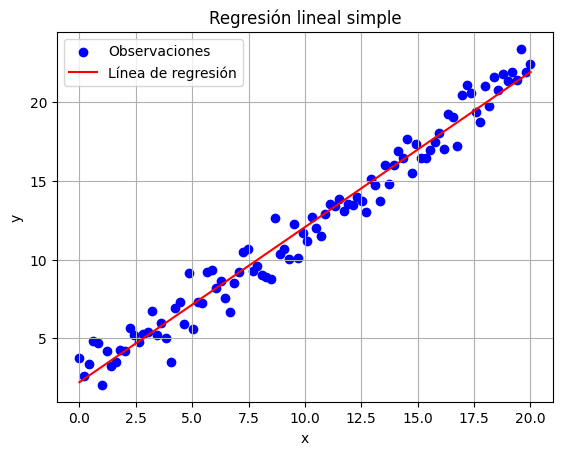

In [5]:
# Graficar las observaciones y la línea de regresión
y_predicha = modelo.predict(x_v)

plt.figure()
plt.scatter(x, y, color="blue", label="Observaciones")
plt.plot(x, y_predicha, color="red", label="Línea de regresión")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión lineal simple")
plt.grid()
plt.legend()
plt.show()

### Verificando la precisión del modelo

¿Cómo medimos qué tan bueno es nuestro modelo para predecir?
- RSE (Residual Standard Error)
- $R^2$

#### $R^2$

El RSE se mide con unidades de $Y$, así que no siempre se puede saber cuál es un buen valor. Imagina que tienes un $Y$ con valores entre $-1$ y $1$, y que tienes otro $Y$ con valores entre $1'000,000$ y $100'000,000$. Los errores cuadrados van a ser mucho mayores en el segundo caso que en el primero, pero esto no significa que el modelo creado en el segundo caso sea malo.

El estadístico $R^2$ es una medida de ajuste. Su valor es la proporción de la varianza sí explicada, así que siempre toma valores entre $0$ y $1$. Su fórmula es:

$$ R^2 = \frac{\text{TSS} - \text{RSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}}$$
$$ \text{TSS} = \sum_{i=1}^n (y_i - \bar{y})^2$$

TSS mide la varianza total de $Y$. RSS mide la varianza que queda sin explicarse después de la regresión. Entonces TSS-RSS mide la varianza que sí está explicada.

$R^2$ mide la proporción de la varianza en $Y$ que puede ser explicada usando $X$.

El estadístico $R^2$ se puede encontrar accediendo a la función `score` del objeto `LinearRegression` de `sklearn`.

- **¿Cuánta varianza queda sin explicar?**

In [6]:
# Calcular R² y la varianza que queda sin explicar
R2 = modelo.score(x_v, y)
varianza_sin_explicar = (1 - R2) * 100

print(f"R²: {R2:.6f}")
print(f"Varianza explicada: {R2 * 100:.2f}%")
print(f"Varianza sin explicar: {varianza_sin_explicar:.2f}%")

R²: 0.970354
Varianza explicada: 97.04%
Varianza sin explicar: 2.96%


## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3